# 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt



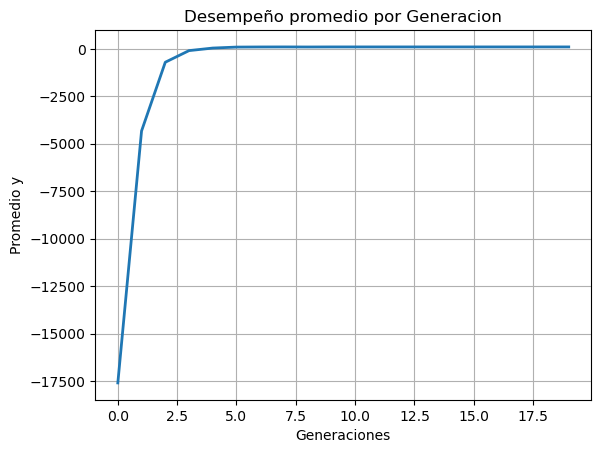

Resultado: x=20.0, y=99.8609


In [2]:
nbits = 8
pobladores = 80  # tiene que ser divisible entre 4 


xpadres = np.random.randint(0,256,pobladores)
yprom = np.zeros(20)

for n in range(20): 
    #funcion de ajuste: y = -(x-20.373)^2 + 100
    y= -(xpadres-20.373)**2 + 100
    yprom[n]= np.mean(y)
    
    #Crear los cromosomas de menor a mayor segun y
    indices_ordenados = np.argsort(y)
    xpadres_ordenados = xpadres[indices_ordenados]
    
    #Los Mejores evaluados 
    mejores_padres = xpadres_ordenados[pobladores//2:] 

    # ------ Decodificar a binario -------
    # Convertimos los numeros decimales a binario (8 columnas)
    padresbin = np.zeros((pobladores// 2, nbits), dtype=int)
    for i, val in enumerate(mejores_padres):
        for j in range(nbits):
            padresbin[i,j] = (int(val) >> j) & 1

    # ------ Cruzamiento -------
    hijobin = np.zeros_like(padresbin)

    for k in range(pobladores// 4):
        # m = valores aleatorios entre 1 y nbits-2
        m= np.random.randint(1, nbits-1)

        # Cruzamiento intercalado partes de la cadena
        padre1= padresbin[2*k]
        padre2= padresbin[2*k+1]

        hijobin[2*k] = np.concatenate((padre1[:m], padre2[m:]))
        hijobin[2*k+1] = np.concatenate((padre2[:m], padre1[m:]))

    # ------ Mutacion -------
    p = np.random.rand()
    if p >= 0.8:
        # Seleccionar aleatoriamente una posicion y un bit
        nhijo = np.random.randint(0, pobladores//2)
        nbit = np.random.randint(0, nbits)

        # Invertir bit: Si es 1 cambia a 0, y viceversa
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]
    
    # ------ Reiniciar proceso -------
    # Cambiar de binario a decimal
    hijodec = np.zeros(pobladores//2)
    for i in range(pobladores//2):
        val = 0
        for j in range(nbits):
            val += hijobin[i,j] * (2**j)
        hijodec[i] = val
    
    # Anexar el nuevo hijo decimal a los xpadres
    xpadres = np.concatenate((mejores_padres, hijodec))

# ------ Mostrar solucion en pantalla -------
# Evaluar la funcion final 
y = -(xpadres-20.373)**2 + 100

# Graficar el promedio 
plt.plot(yprom, linewidth=2)
plt.title('Desempeño promedio por Generacion')
plt.xlabel('Generaciones')
plt.ylabel('Promedio y')
        
plt.grid(True)
plt.show()

# Ubicar el maximo 
val = np.max(y)
ind = np.argmax(y)

print(f'Resultado: x={xpadres[ind]}, y={val:.4f}')



